In [2]:
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np

base_dir = Path("solutions2.ipynb").resolve().parent
figures_dir = base_dir / "figures"
figures_dir.mkdir(exist_ok="True")

In [3]:
from matplotlib.pyplot import rcParams

rcParams.update({
    "font.size": 18,
    "axes.titlesize": 22,
    "axes.labelsize": 20,
    "axes.linewidth": 2,
    "xtick.labelsize": 18,
    "ytick.labelsize": 18,
    "xtick.major.width": 2,
    "ytick.major.width": 2,
    "legend.fontsize": 16,
    "lines.linewidth": 3,
    "lines.markersize": 8
})

In [4]:
# problem 6.10 from Newman 
# using the relaxation method to solve for x for c=2
# physics of contact pocesses, mathematical models of epidemics, and theory of random graphs

def f(x, c):
    return 1 - np.exp(-c * x)

def f_prime(x,c):
    return c * np.exp(-c * x)

# derivative of f(x) on RHS is c exp(-cx) which is less than 1 for x>0.35 for c=2, so let x0 = 0.5 so method stable
# (a)
c = 2
x0 = 0.5
tolerance = 1e-7

for i in range(30):
    x0, x_old = f(x0,c), x0
    error = (x_old - x0) / (1 - 1/f_prime(x_old,c))
    print(f"{x0}, error: {error}")
    if np.abs(x_old - x0) < tolerance:
        break

0.6321205588285577, error: 0.36787944117144233
0.7175464361494597, error: 0.110913531480565
0.7619067492797049, error: 0.0403269147709922
0.7821205821947897, error: 0.015610977805616532
0.7907532631816485, error: 0.006212691499064951
0.794334975085306, error: 0.002502702465751769
0.7958029765851733, error: 0.0010133824213059658
0.7964016204183796, error: 0.0004112086641607746
0.7966452403764663, error: 0.00016700513365174664
0.7967442987979305, error: 6.785029736454325e-05
0.7967845631871013, error: 2.7569983241325462e-05
0.7968009272190715, error: 1.1203321210770777e-05
0.7968075774224933, error: 4.552683444438361e-06
0.7968102799464087, error: 1.8500877999034894e-06
0.7968113781935964, error: 7.518287668643491e-07
0.7968118244957711, error: 3.0552463591922194e-07
0.7968120058623394, error: 1.2415774453190693e-07
0.7968120795653444, error: 5.0454686157816125e-08


Converged after 4467 iterations with max error 0.00022351258059650657


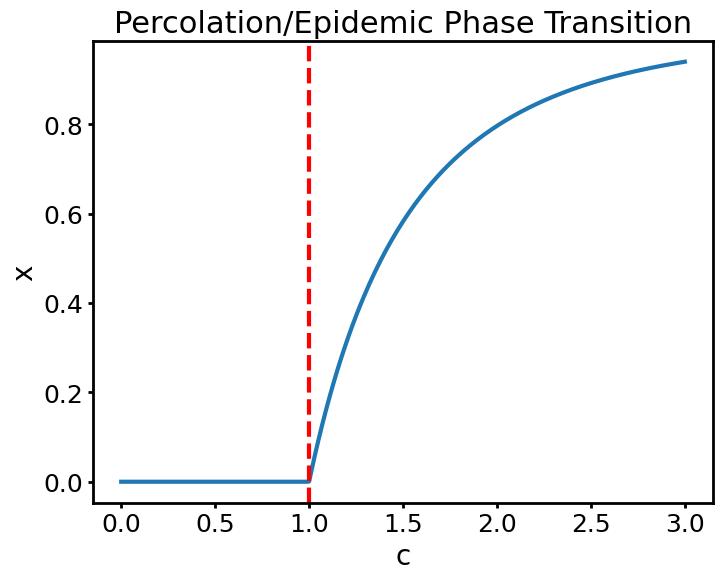

In [5]:
# problem 6.10 from Newman 
# (b) now let's do values of c from 0 to 3 in steps of 0.01

c_values = np.arange(0, 3.01, 0.01)
x0_list = np.array([])
tolerance = 1e-7
max_iterations = 10000

for c in c_values:
    if c > 0:
        x0_threshold =  (np.log(c)/c)
        x0 = max(0.5, x0_threshold + 0.5)
    else:
        x0 = 1 # by inspection we see that x=1 is the solution for c = 0
    x0_list = np.append(x0_list, x0)

for i in range(max_iterations):
    x0_list, x_old_list = f(x0_list, c_values), x0_list
    error = np.zeros_like(x0_list)
    nonzero_c = c_values > 0
    error[nonzero_c] = ((x_old_list[nonzero_c] - x0_list[nonzero_c])/ (1- 1 / f_prime(x_old_list[nonzero_c], c_values[nonzero_c])))
    if np.max(np.abs(x_old_list - x0_list)) < tolerance:
        print(f"Converged after {i+1} iterations with max error {np.max(np.abs(error))}")
        break

fig = plt.figure(figsize=(8,6))
plt.plot(c_values, x0_list)
plt.xlabel("c")
plt.ylabel("x")
plt.axvline(x=1, color='r', linestyle='--', label='c=1')
plt.title("Percolation/Epidemic Phase Transition")
fig.savefig(figures_dir / "phase_transition.png")
plt.show()


In [6]:
# problem 6.11 from Newman
# overrelaxation

# (b) 

def f(x, c):
    return 1 - np.exp(-c * x)

def f_prime(x,c):
    return c * np.exp(-c * x)

# derivative of f(x) on RHS is c exp(-cx) which is less than 1 for x>0.35 for c=2, so let x0 = 0.5 so method stable
# (a)
c = 2
x0 = 0.5
tolerance = 1e-7

for i in range(30):
    x0, x_old = f(x0,c), x0
    error = (x_old - x0) / (1 - 1/f_prime(x_old,c))
    print(f"{x0}, error: {error}")
    if np.abs(x_old - x0) < tolerance:
        break

print(f"Converged to {x0} after {i+1} iterations with error {error}")


0.6321205588285577, error: 0.36787944117144233
0.7175464361494597, error: 0.110913531480565
0.7619067492797049, error: 0.0403269147709922
0.7821205821947897, error: 0.015610977805616532
0.7907532631816485, error: 0.006212691499064951
0.794334975085306, error: 0.002502702465751769
0.7958029765851733, error: 0.0010133824213059658
0.7964016204183796, error: 0.0004112086641607746
0.7966452403764663, error: 0.00016700513365174664
0.7967442987979305, error: 6.785029736454325e-05
0.7967845631871013, error: 2.7569983241325462e-05
0.7968009272190715, error: 1.1203321210770777e-05
0.7968075774224933, error: 4.552683444438361e-06
0.7968102799464087, error: 1.8500877999034894e-06
0.7968113781935964, error: 7.518287668643491e-07
0.7968118244957711, error: 3.0552463591922194e-07
0.7968120058623394, error: 1.2415774453190693e-07
0.7968120795653444, error: 5.0454686157816125e-08
Converged to 0.7968120795653444 after 18 iterations with error 5.0454686157816125e-08


In [7]:
# problem 6.11 from Newman
# overrelaxation

# (c)

def f(x, c, omega):
    return (1+ omega) * (1 - np.exp(-c * x)) - (omega * x)

def f_prime(x,c):
    return c * np.exp(-c * x)

def factor(x, c, omega):
    return (1+omega) * f_prime(x,c) - omega

omega = 0.5
c = 2
x0 = 0.5
tolerance = 1e-7

for i in range(30):
    x0, x_old = f(x0,c, omega), x0
    error = (x_old - x0) / (1 - 1/factor(x_old,c, omega))
    print(f"{x0}, error: {error}")
    if np.abs(x_old - x0) < tolerance:
        break

print(f"Converged to {x0} after {i+1} iterations with error {error}")


0.6981808382428365, error: 0.30181916175716345
0.779665884469, error: 0.026084181604141207
0.7947522513991616, error: 0.0022708361581686735
0.7965838522874732, error: 0.0002311986647204165
0.7967870873179381, error: 2.5078397396155407e-05
0.796809385868891, error: 2.744580475447274e-06
0.7968118293563258, error: 3.0066884922447984e-07
0.7968120970781651, error: 3.29419167000284e-08
0.7968121264107908, error: 3.609229940900513e-09
Converged to 0.7968121264107908 after 9 iterations with error 3.609229940900513e-09


In [8]:
# problem 6.11 from Newman
# overrelaxation

# (c) continued -- different values of omega

def f(x, c, omega):
    return (1+ omega) * (1 - np.exp(-c * x)) - (omega * x)

def f_prime(x,c):
    return c * np.exp(-c * x)

def factor(x, c, omega):
    return (1+omega) * f_prime(x,c) - omega

omega_values = np.arange(0.2, 1.5, 0.1)
c = 2
tolerance = 1e-7

for omega in omega_values:
    x0 = 0.5
    for i in range(30):
        x0, x_old = f(x0,c, omega), x0
        error = (x_old - x0) / (1 - 1/factor(x_old,c, omega))
        if np.abs(x_old - x0) < tolerance:
            break
    print(f"omega = {omega:.1f}, x = {x0:.10f}, error = {abs(error):.3e}, iterations = {i + 1}")

omega = 0.2, x = 0.7968121119, error = 1.813e-08, iterations = 14
omega = 0.3, x = 0.7968121139, error = 1.617e-08, iterations = 12
omega = 0.4, x = 0.7968121104, error = 1.961e-08, iterations = 10
omega = 0.5, x = 0.7968121264, error = 3.609e-09, iterations = 9
omega = 0.6, x = 0.7968121267, error = 3.354e-09, iterations = 7
omega = 0.7, x = 0.7968121300, error = 1.682e-11, iterations = 6
omega = 0.8, x = 0.7968121279, error = 2.135e-09, iterations = 7
omega = 0.9, x = 0.7968121276, error = 2.394e-09, iterations = 9
omega = 1.0, x = 0.7968121381, error = 8.034e-09, iterations = 10
omega = 1.1, x = 0.7968121148, error = 1.520e-08, iterations = 11
omega = 1.2, x = 0.7968121434, error = 1.334e-08, iterations = 12
omega = 1.3, x = 0.7968121152, error = 1.478e-08, iterations = 14
omega = 1.4, x = 0.7968121534, error = 2.340e-08, iterations = 17


f_x crosses 0 near x = [-3.50350350e-03  4.96246246e+00]


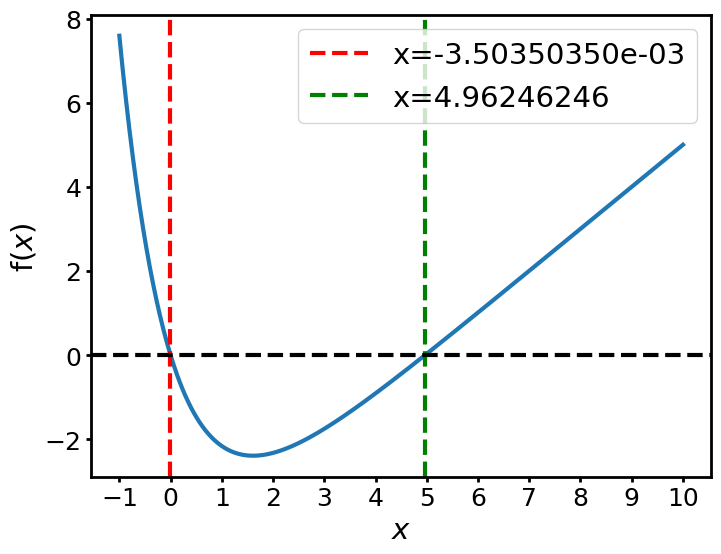

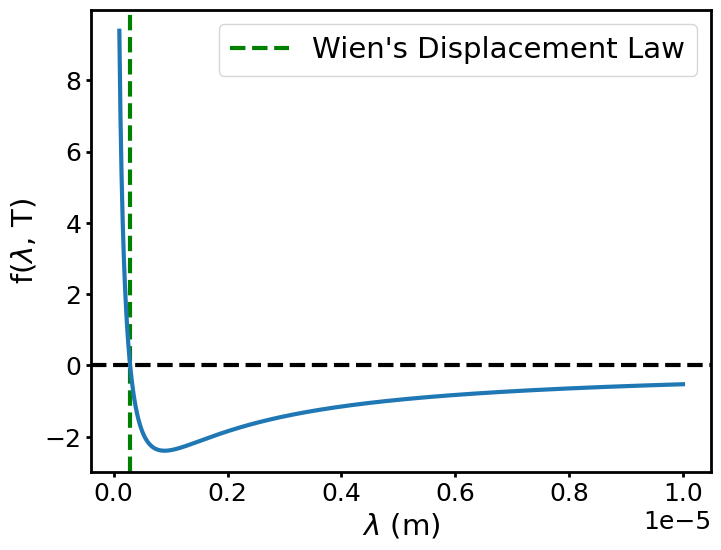

In [18]:
# problem 6.13 from Newman: Wien's Displacement Constant]

# Planck's radiation law:

h = 6.62607015e-34  # m^2 kg s^-1
c = 299792458 # m/s
k_B = 1.380649e-23 # m^2 kg s^-2 K^-1

def I(lam, T):
    numerator = 2 * np.pi * h * c**2 * lam**(-5)
    denominator = np.expm1x(np.divide(h*c, lam*k_B * T))
    return numerator / denominator

# (a) After differentiation I(lambda, T) wrt to lambda, we get the following equation

T = 10000 # K

def f(lam, T):
    return 5 * np.exp( -(h*c)/(lam*k_B*T)) + (h*c / (lam*k_B*T)) - 5

lam = np.linspace(1e-7, 1e-5, 1000)

# as we can see, the root of this is a maximum since I'(lambda) cross 0 from positive to negative
# now substituting x = hc/(lam kB T)

def f_x(x):
    return 5*np.exp(-x) + x - 5

def wien_displacement_law(x, T):
    b = (h*c)/(k_B * x)
    return b/T

x = np.linspace(-1, 10, 1000)

# we can see the x we're interested in is when f_x intersects 0 for the first time -- let's solve for this intersection

print(f"f_x crosses 0 near x = {((x[:-1] + x[1:]) / 2)[f_x(x)[:-1] * f_x(x)[1:] < 0]}") # shows midpoint of each pair of xs where f(x) changes signs
fig = plt.figure(figsize=(8,6))
plt.plot(x, f_x(x))
plt.axvline(-3.50350350e-03, color = "red", linestyle = "--", label = "x=-3.50350350e-03")
plt.axvline(4.96246246, color = "green", linestyle = "--", label = "x=4.96246246")
plt.xlabel(r"$x$", fontsize=21)
plt.ylabel(r"f($x$)", fontsize=21)
plt.axhline(y=0, color = "black", linestyle = "--")
plt.legend(fontsize=21)
plt.xticks(np.arange(min(x), max(x) + 1, 1))
fig.savefig(figures_dir / "f_x_plot.png")
plt.show()

fig = plt.figure(figsize=(8,6))
plt.axhline(y=0, color = "black", linestyle = "--")
plt.axvline(wien_displacement_law(4.96246246, T), color = "green", linestyle = "--", label = "Wien's Displacement Law")
plt.xlabel(r"$\lambda$ (m)", fontsize=21)
plt.ylabel(r"f($\lambda$, T)", fontsize=21)
plt.plot(lam, f(lam, T))
plt.legend(fontsize=21)
fig.savefig(figures_dir / "f_lambda_plot.png")
plt.show()

Converged to x = 4.965114206075668 after 23 iterations with f_x(x) = -2.477313909565737e-08
Wien's displacement law: lambda_max = 2.8977719701660506e-07 m


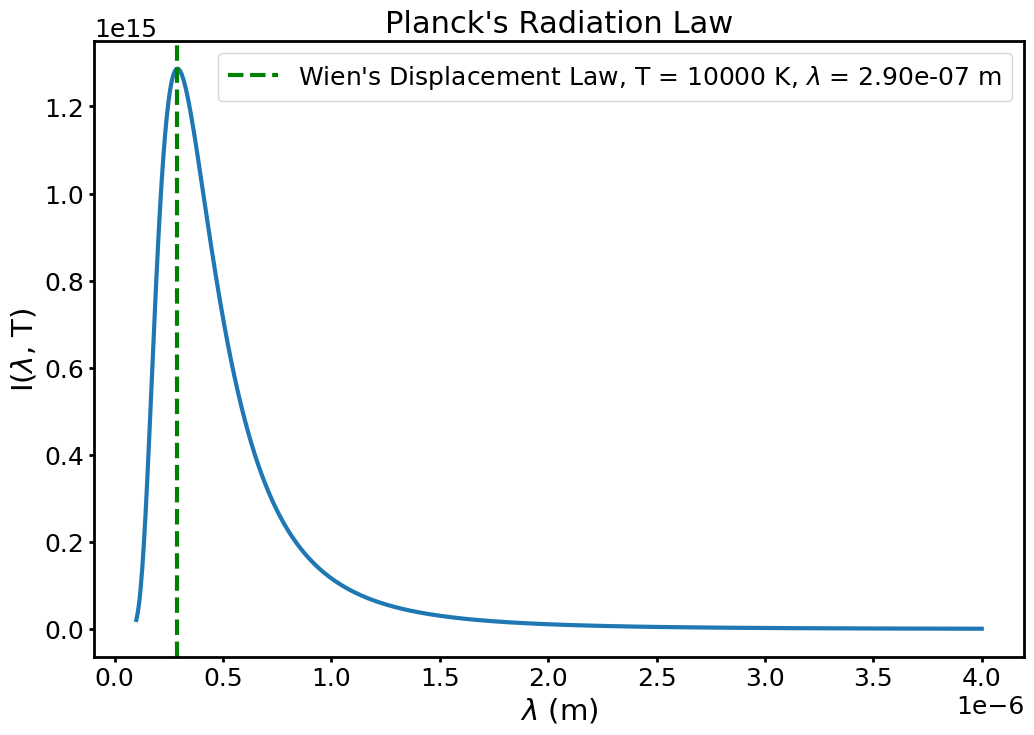

Surface temperature of the Sun: 5772.454123836754 K


In [19]:
# (b) solve equation to an accuracy of 1e-6 using binary search method, finding value for the dispalcement constant

# ignoring the intersection we just did, by simply plotting f_x(x) we can see that a good initial guess for the root is between x = 4.5 and 5

x1 = 4.5
x2 = 5
max_iterations = 10000
tolerance = 1e-7

if f_x(x1) * f_x(x2) > 0:
    raise ValueError("x1 and x2 don't enclose a root")

for i in range(max_iterations):
    x_prime = (x1 + x2) / 2
    if f_x(x_prime) * f_x(x1) <0:
        x2 = x_prime
    else:
        x1 = x_prime

    if np.abs(x1-x2) < tolerance:
        x_prime = (x1 +x2)/2
        break

print(f"Converged to x = {x_prime} after {i+1} iterations with f_x(x) = {f_x(x_prime)}")

# for T = 10000 K, we can find the wavelength peak using Wien's displacement law

print(f"Wien's displacement law: lambda_max = {wien_displacement_law(x_prime, T)} m") # ultraviolet regime
lam = np.linspace(1e-7, 4e-6, 1000)
fig = plt.figure(figsize=(12,8))
plt.plot(lam, I(lam, T))
plt.axvline(wien_displacement_law(x_prime, T), color = "green", linestyle = "--", label = rf"Wien's Displacement Law, T = 10000 K, $\lambda$ = {wien_displacement_law(x_prime, T):.2e} m")
plt.xlabel(r"$\lambda$ (m)", fontsize=21)
plt.ylabel(r"I($\lambda$, T)", fontsize=21)

plt.title("Planck's Radiation Law", fontsize=22)
plt.legend(fontsize=18)
fig.savefig(figures_dir / "plancks_radiation_law.png")
plt.show()

# (c) optical pyrometry: Sun's wavelength peak is 502 nm. Estimate surface temperature of the Sun

lambda_sun = 502e-9  # m
def temperature_from_wien(lamb):
    b = (h*c)/(k_B * x_prime)
    T = b / lamb
    return T

print(f"Surface temperature of the Sun: {temperature_from_wien(lambda_sun)} K")

In [20]:
# Stellar Mass Function from COSMOS galaxy survey

cosmos = base_dir / "smf_cosmos.dat"
# columns: 1) log M_gal [dex], 2) n(M_gal) [1/dex/Volume], 3) error in n(M_gal)
df = pd.read_csv(cosmos, sep = r"\s+", header = None, usecols=[0, 1, 2], names = ["log_M_gal", "n_M_gal", "error_n_M_gal"])

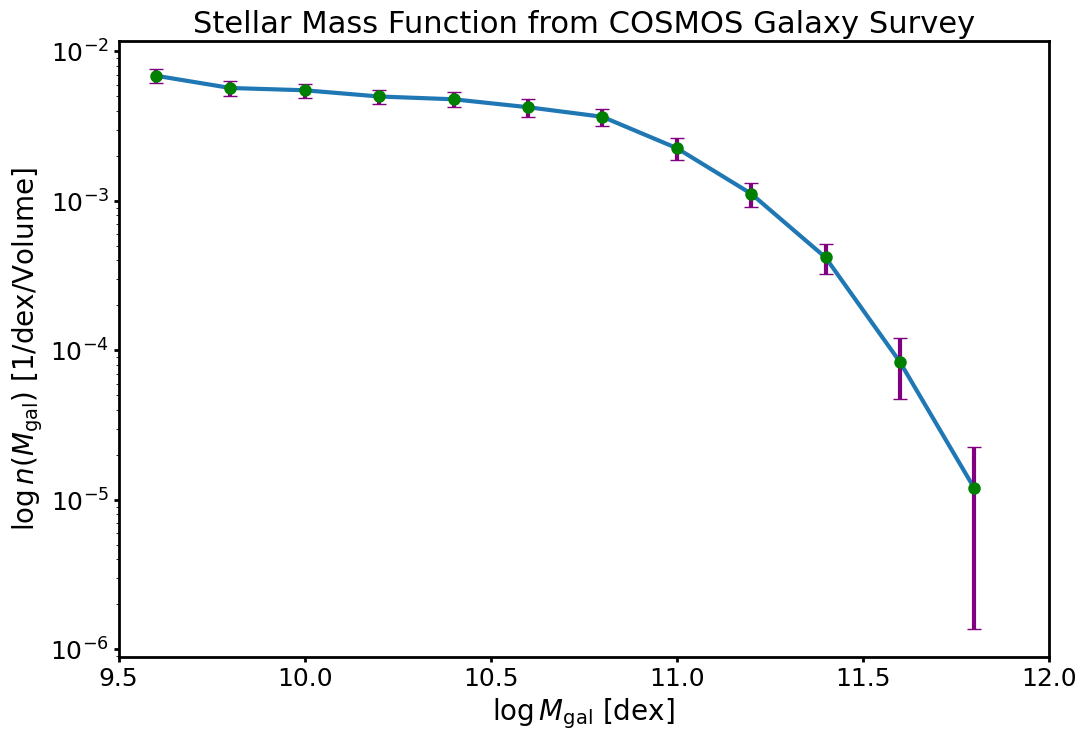

In [21]:
fig = plt.figure(figsize=(12,8))
plt.plot(df["log_M_gal"], df["n_M_gal"])
plt.yscale("log")
plt.errorbar(df["log_M_gal"], df["n_M_gal"], yerr=df["error_n_M_gal"], fmt = "o", color = "green",  capsize=5, ecolor='purple')
plt.xlim(9.5,12)
plt.xlabel(r"$\log M_{\text{gal}}$ [dex]")
plt.ylabel(r"$\log n(M_{\text{gal}})$ [1/dex/Volume]")
plt.title("Stellar Mass Function from COSMOS Galaxy Survey")
fig.savefig(figures_dir / "stellar_mass_function.png")
plt.show()

Converged to x = 2.000000266212374, y = 2.000000266212374 after 78 iterations with f(x,y) = 1.4173805605919292e-13


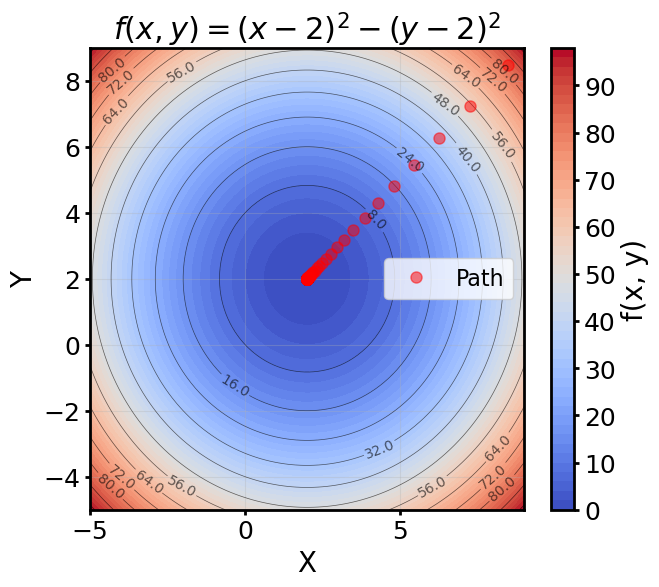

In [22]:
# let's first find the minimum of f(x,y) implementing the gradient of descent method in multiple dimensions using numerical derivatives.

def f(x,y):
    return (x-2)**2 + (y-2)**2

x = np.linspace(-5,9,100)
y = np.linspace(-5,9,100)

x0 = 10
y0 = 10
gamma = 0.1 # learning rate

# from hw 1 we choose to do richardson extrapolation, highest order of accuracy

def central_difference(f, x, h):
    x = np.float32(x)
    h = np.float32(h)
    return (f(x+h) - f(x-h)) / (np.float32(2)*h)

def extrapolated_difference(f, x, h, n):
    x = np.float32(x)
    h = np.float32(h)
    F = np.zeros((n,n), dtype=np.float32)

    for i in range(n):
        hi = h/np.float32(2**i)
        F[i,0] = central_difference(f, x, hi)

    for j in range(1,n):
        for i in range(j, n):
            F[i,j] = (np.float32(1)/(np.float32(4**j) - np.float32(1))) * (np.float32(4**j) * F[i, j-1] - F[i-1, j-1])

    return F[n-1, n-1]

def gradient(f, x, y, h = 1e-5, n=2):
    df_dx = extrapolated_difference(lambda x: f(x, y), x, h, n)
    df_dy = extrapolated_difference(lambda y: f(x, y), y, h, n)
    return np.array([df_dx, df_dy])

x_path_list = []
y_path_list = []

def gradient_descent(f, x0, y0, gamma, tolerance=1e-7, max_iterations=10000):
    x, y = x0, y0
    for i in range(max_iterations):
        grad = gradient(f,x,y)
        x_new = x-gamma * grad[0]
        y_new = y-gamma * grad[1]
        if np.sqrt((x_new - x)**2 + (y_new - y)**2) < tolerance:
            break
        x_path_list.append(x_new)
        y_path_list.append(y_new)
        x, y = x_new, y_new
    return x, y, i+1

x_f, y_f, iterations = gradient_descent(f, x0, y0, gamma)
print(f"Converged to x = {x_f}, y = {y_f} after {iterations} iterations with f(x,y) = {f(x_f,y_f)}")

X, Y = np.meshgrid(x, y)
Z = f(X,Y)

# plotting path of gradient descent on contour plot of f(x,y)

fig = plt.figure(figsize=(7, 6))
contours = plt.contourf(X, Y, Z, levels=50, cmap='coolwarm')
contour_lines = plt.contour(X, Y, Z, levels=15, colors='black', linewidths=0.5, alpha=0.6)
plt.clabel(contour_lines, inline=True, fontsize=10, fmt='%.1f')
plt.plot(x_path_list, y_path_list, 'ro', alpha=0.5, label='Path')
plt.title(r'$f(x,y) = (x-2)^2 - (y-2)^2$')
plt.xlabel('X')
plt.ylabel('Y')
plt.colorbar(contours, label='f(x, y)')
plt.legend()
plt.grid(True, alpha=0.3)
fig.savefig(figures_dir / "gradient_descent_path.png")
plt.show()

In [23]:
# applying to the Schechter function now

log_M_gal_data = df["log_M_gal"].to_numpy(dtype=float)
n_M_gal_data = df["n_M_gal"].to_numpy(dtype=float)
error_n_M_gal_data = df["error_n_M_gal"].to_numpy(dtype=float)

def schechter_function(log_phi_star, log_M_star, alpha, log_M_gal):
    phi_star = 10**log_phi_star
    mass_ratio = 10**(log_M_gal-log_M_star)
    factor = mass_ratio**(alpha + 1)
    exp_term = np.exp(-mass_ratio)
    n_M_gal = phi_star*factor*exp_term*np.log(10)
    return n_M_gal

def chi_squared(log_phi_star, log_M_star, alpha, log_M_gal):
    n_model = schechter_function(log_phi_star, log_M_star, alpha, log_M_gal)
    chi2 = np.sum(((n_model - n_M_gal_data) / error_n_M_gal_data)**2)
    return chi2

def gradient_schechter(chi_squared, log_phi_star, log_M_star, alpha, log_M_gal, h=1e-5, n=2):
    df_dlog_phi_star = extrapolated_difference(lambda p: chi_squared(p, log_M_star, alpha, log_M_gal), log_phi_star, h, n)
    df_dlog_M_star = extrapolated_difference(lambda M: chi_squared(log_phi_star, M, alpha, log_M_gal), log_M_star, h, n)
    df_dalpha = extrapolated_difference(lambda a: chi_squared(log_phi_star, log_M_star, a, log_M_gal), alpha, h, n)
    return np.array([df_dlog_phi_star, df_dlog_M_star, df_dalpha])

log_phi_star0 = -3.0
log_M_star0 = 10.5
alpha0 = -1.5
gamma = 1e-5

log_phi_star_path_list = []
log_M_star_path_list = []
alpha_path_list = []

def gradient_descent_schechter(chi_squared, log_phi_star0, log_M_star0, alpha0, gamma, tolerance=1e-7, max_iterations=10000):
    log_phi_star, log_M_star, alpha = log_phi_star0, log_M_star0, alpha0
    log_phi_star_path_list.clear()
    log_M_star_path_list.clear()
    alpha_path_list.clear()

    log_phi_star_path_list.append(log_phi_star)
    log_M_star_path_list.append(log_M_star)
    alpha_path_list.append(alpha)

    for i in range(max_iterations):
        grad = gradient_schechter(chi_squared, log_phi_star, log_M_star, alpha, log_M_gal_data)
        log_phi_star_new = np.clip(log_phi_star - gamma*grad[0], -8, 0-1e-5)
        log_M_star_new = np.clip(log_M_star - gamma*grad[1], 7, 15)
        alpha_new = np.clip(alpha - gamma*grad[2], -3, 0.1)
        dist = np.sqrt((log_phi_star_new-log_phi_star)**2 + (log_M_star_new-log_M_star)**2 + (alpha_new-alpha)**2)
        log_phi_star, log_M_star, alpha = log_phi_star_new, log_M_star_new, alpha_new
        log_phi_star_path_list.append(log_phi_star)
        log_M_star_path_list.append(log_M_star)
        alpha_path_list.append(alpha)
        if dist < tolerance:
            break

    return log_phi_star, log_M_star, alpha, i+1

log_phi_star_f, log_M_star_f, alpha_f, iterations = gradient_descent_schechter(chi_squared, log_phi_star0, log_M_star0, alpha0, gamma)

print(f"Converged to log_phi_star = {log_phi_star_f}, log_M_star = {log_M_star_f}, alpha = {alpha_f} after {iterations} iterations with chi_squared = {chi_squared(log_phi_star_f, log_M_star_f, alpha_f, log_M_gal_data)}")

Converged to log_phi_star = -2.568248982457048, log_M_star = 10.976248207277138, alpha = -1.0094230815454834 after 4319 iterations with chi_squared = 2.908056145730044


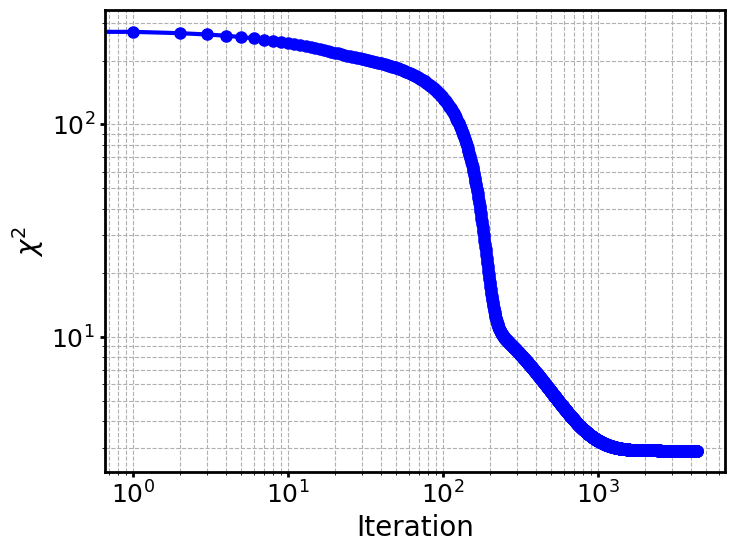

In [24]:
# chi^2 as a function of step i

fig = plt.figure(figsize=(8,6))
chi2_values = [chi_squared(log_phi_star_path_list[i], log_M_star_path_list[i], alpha_path_list[i], log_M_gal_data) for i in range(len(log_phi_star_path_list))]
plt.loglog(range(len(chi2_values)), chi2_values, marker='o', color='blue')
plt.xlabel('Iteration')
plt.ylabel(r'$\chi^2$')
fig.savefig(figures_dir / "chi2_convergence.png")
plt.grid(True, which="both", ls="--")   

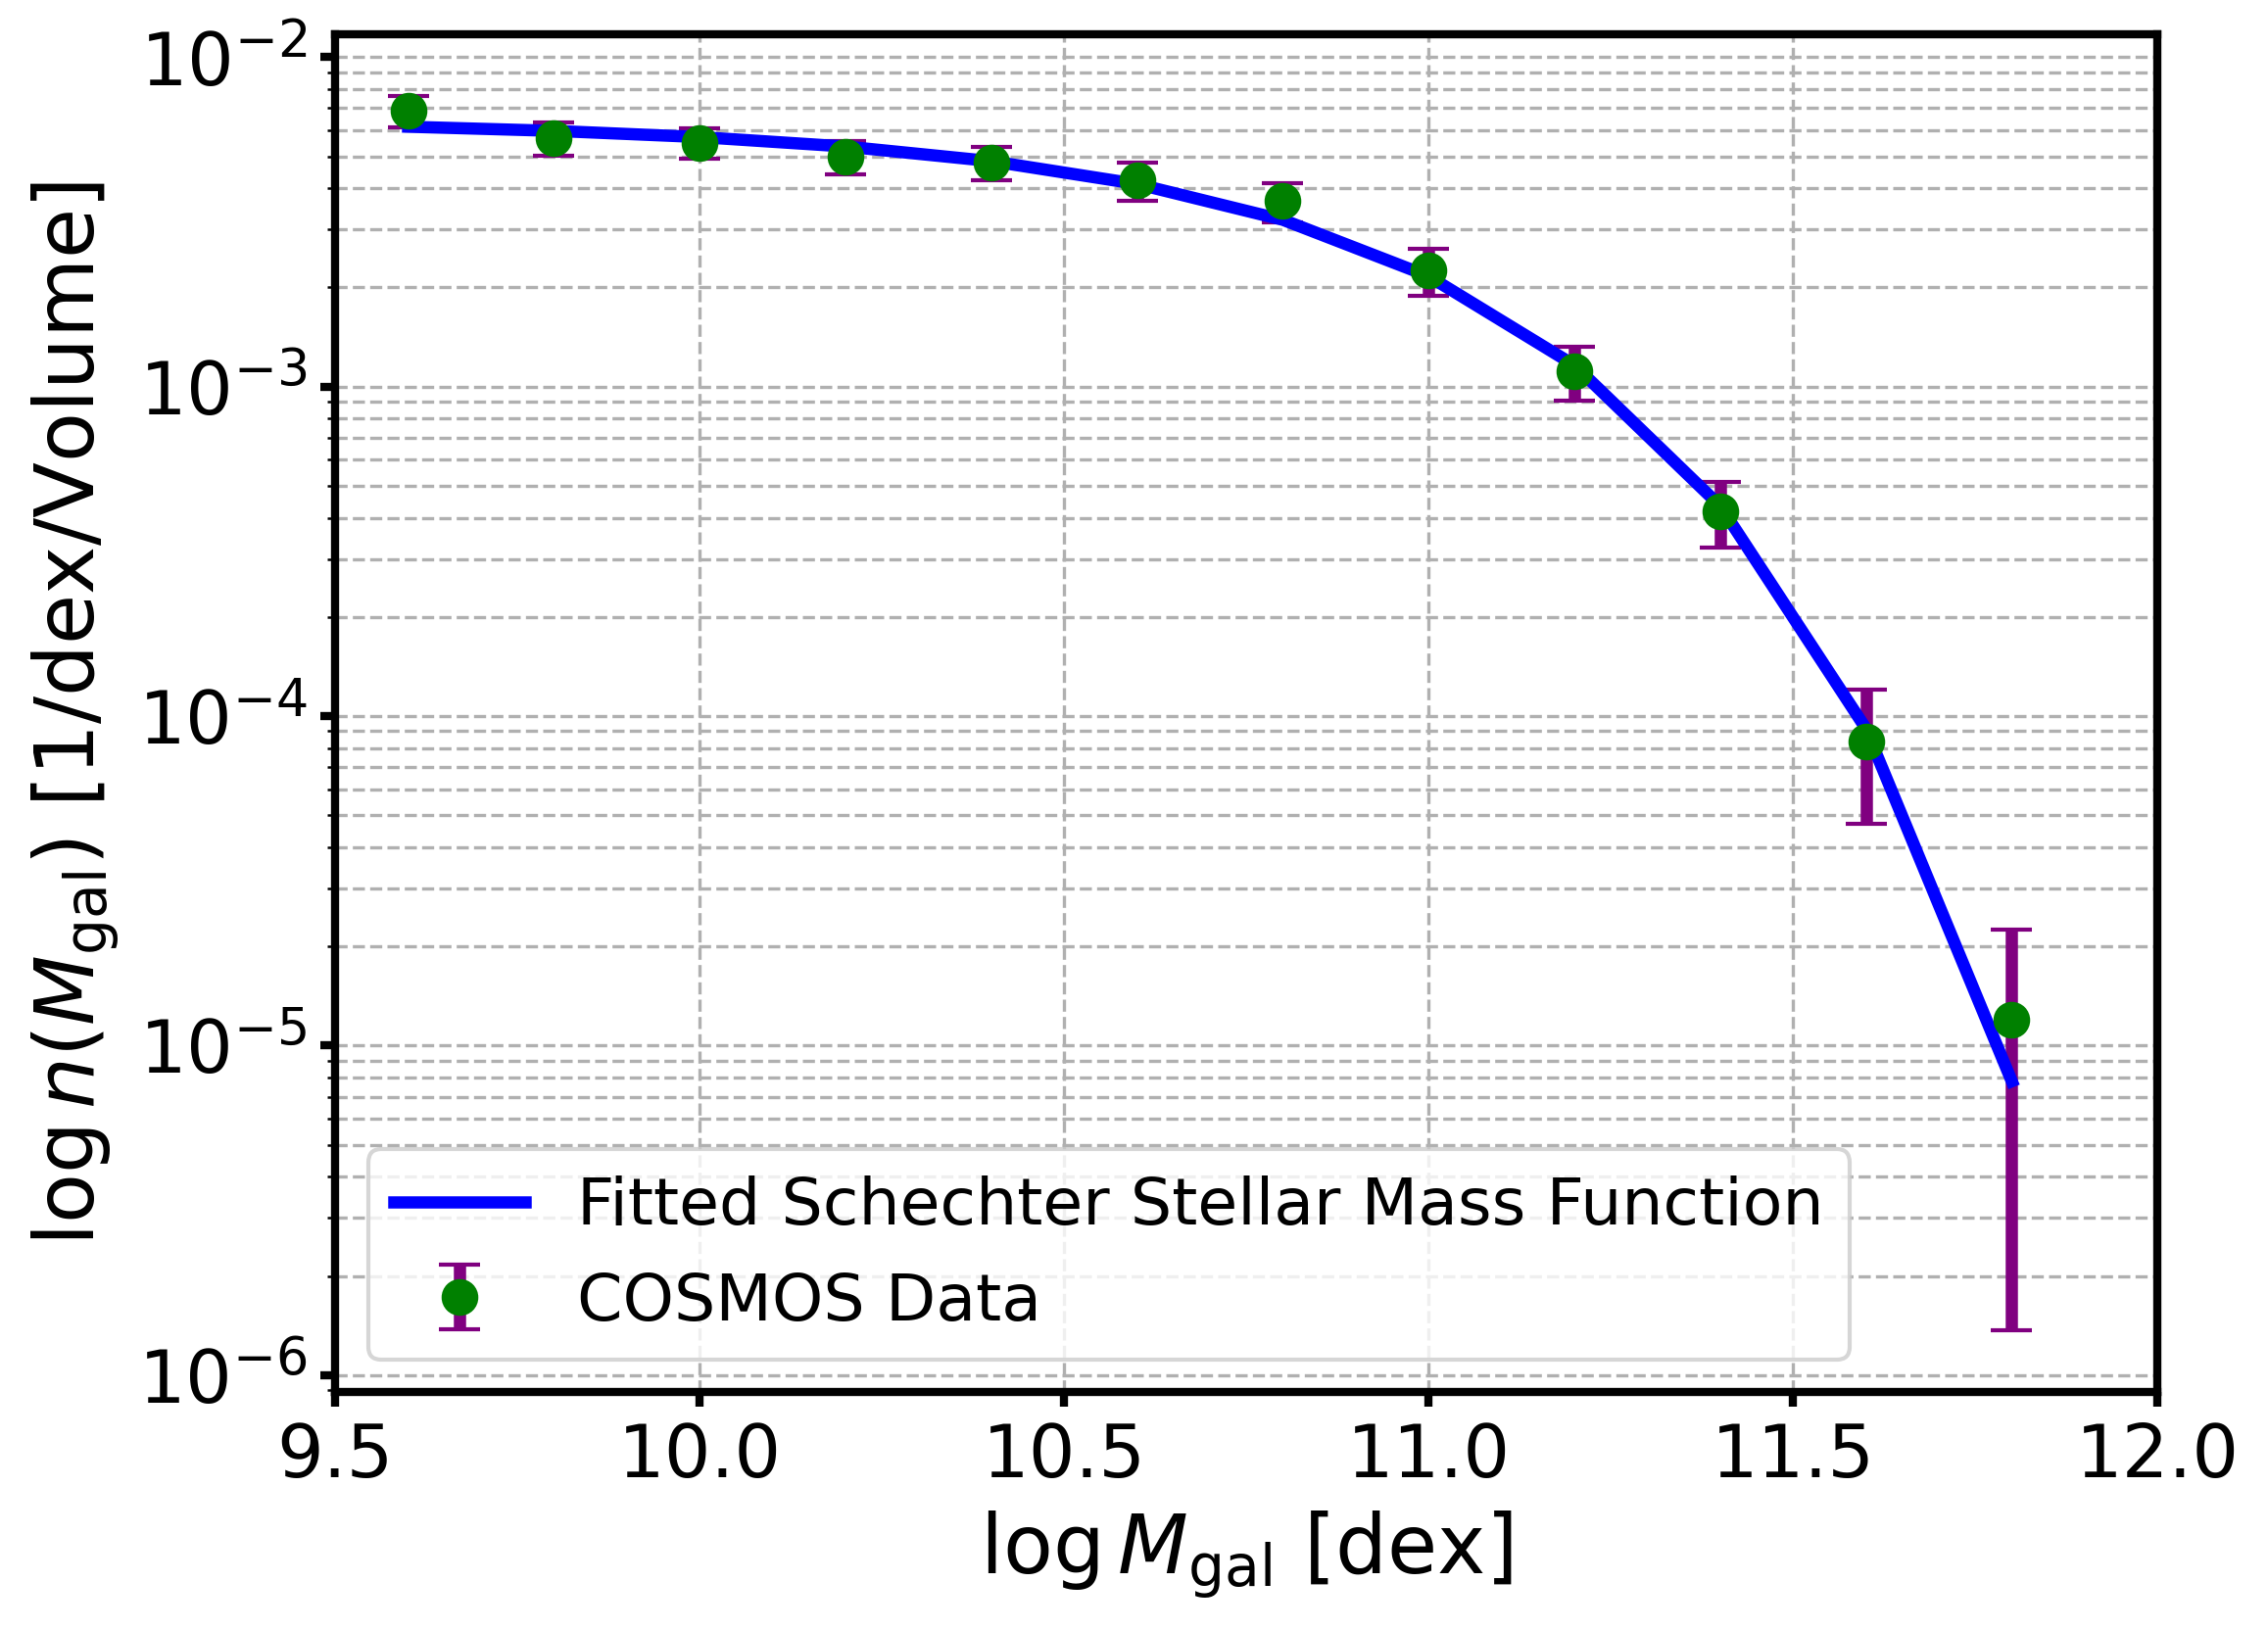

In [25]:
# plotting schechter function with fitted parameters

fig = plt.figure(figsize=(8,6),dpi=300)
plt.errorbar(log_M_gal_data, n_M_gal_data, yerr=error_n_M_gal_data, fmt='o', color='green', capsize=5, ecolor='purple', label='COSMOS Data')
plt.plot(log_M_gal_data, schechter_function(log_phi_star_f, log_M_star_f, alpha_f, log_M_gal_data), label='Fitted Schechter Stellar Mass Function', color='blue')
plt.xlim(9.5,12)
plt.yscale("log")
plt.xlabel(r"$\log M_{\text{gal}}$ [dex]")
plt.ylabel(r"$\log n(M_{\text{gal}})$ [1/dex/Volume]")
plt.legend()
plt.grid(True, which="both", ls="--")  
fig.savefig(figures_dir / "schechter.png", bbox_inches="tight")
plt.show()    

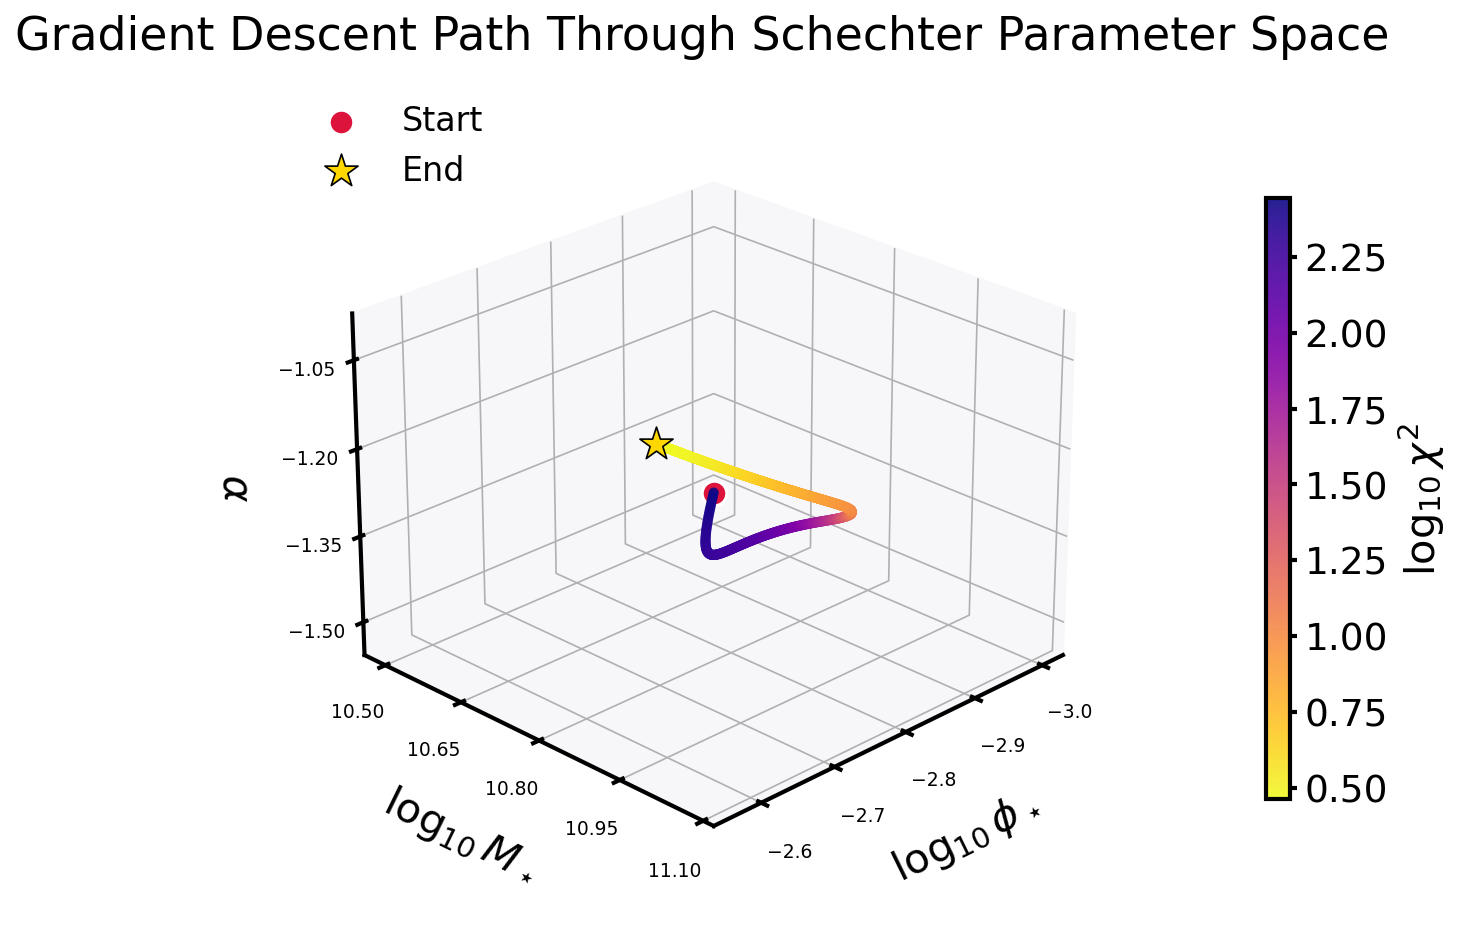

In [26]:
path = np.column_stack([log_phi_star_path_list, log_M_star_path_list, alpha_path_list])
log_chi2 = np.log10(np.maximum([chi_squared(*p, log_M_gal_data) for p in path], 1e-300))
step = max(1, len(path) // 5000)  
x, y, z = path[::step].T
c = log_chi2[::step]
plt.rcParams.update({"font.size": 11})

fig = plt.figure(figsize=(10, 8), dpi=150)
ax = fig.add_subplot(projection="3d")
ax.plot(x, y, z, color="0.35", lw=0.8, alpha=0.5)
sc = ax.scatter(x, y, z, c=c, cmap="plasma_r", s=24, alpha=0.9, edgecolor="none", depthshade=False)
ax.scatter(*path[0], color="crimson", s=140, marker="o", edgecolor="white", lw=1.5, depthshade=False, label="Start")
ax.scatter(*path[-1], color="gold", s=280, marker="*", edgecolor="black", lw=0.8, depthshade=False, label="End")
ax.set_xlabel(r"$\log_{10}\phi_\star$", labelpad=20)
ax.set_ylabel(r"$\log_{10}M_\star$", labelpad=20)
ax.set_zlabel(r"$\alpha$", labelpad=16)
ax.set_title("Gradient Descent Path Through Schechter Parameter Space", pad=12)

for axis in (ax.xaxis, ax.yaxis, ax.zaxis):
    axis.set_pane_color((0.97, 0.97, 0.98, 1))
    axis._axinfo["axisline"]["linewidth"] = 0.8
    axis.set_major_locator(plt.MaxNLocator(5)) 
ax.tick_params(axis="x", pad=8, labelsize=9)
ax.tick_params(axis="y", pad=8, labelsize=9)
ax.tick_params(axis="z", pad=6, labelsize=9)

fig.colorbar(sc, ax=ax, pad=0.12, shrink=0.65, aspect=25, label=r"$\log_{10}\chi^2$")
ax.legend(frameon=False, loc="upper left")
ax.grid(alpha=0.25)
ax.view_init(elev=25, azim=45)
ax.set_box_aspect(None, zoom=0.92)
fig.savefig(figures_dir / "schechter_3d_path.png", bbox_inches="tight", dpi=300)
plt.show()

In [28]:
# robustness check, starting at different initial positions in parameter space

initial_guesses = [(-3.0, 10.5, -1.5), (-2.5, 11.0, -1.0), (-3.5, 10.0, -2.0), (-4.0, 11.5, -1.9)]

for log_phi_star0, log_M_star0, alpha0 in initial_guesses:
    log_phi_star_f, log_M_star_f, alpha_f, iterations = gradient_descent_schechter(chi_squared, log_phi_star0, log_M_star0, alpha0, gamma)
    print(
        f"Start = ({log_phi_star0}, {log_M_star0}, {alpha0}),"
        f"Final = ({log_phi_star_f:.6f}, {log_M_star_f:.6f}, {alpha_f:.6f}),"
        f"chi^2 = {chi_squared(log_phi_star_f, log_M_star_f, alpha_f, log_M_gal_data):.6f}"
    )

Start = (-3.0, 10.5, -1.5),Final = (-2.568249, 10.976248, -1.009423),chi^2 = 2.908056
Start = (-2.5, 11.0, -1.0),Final = (-2.568182, 10.976205, -1.009357),chi^2 = 2.908056
Start = (-3.5, 10.0, -2.0),Final = (-2.568249, 10.976248, -1.009423),chi^2 = 2.908056
Start = (-4.0, 11.5, -1.9),Final = (-2.568249, 10.976248, -1.009423),chi^2 = 2.908056
